In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
# 步骤一：导入相关库
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [6]:
# 步骤二：加载数据集
# 2.1 设置数据路径和图像尺寸
data_dir = "./airplane"
image_size = (64, 64)
os.makedirs('./output', exist_ok=True)

# 2.2 定义读取图像文件夹的函数
def load_image_folder(path):
    X = []
    y = []
    class_names = sorted(os.listdir(path))
    for label, cls in enumerate(class_names):
        cls_path = os.path.join(path, cls)
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(cls_path, fname)
                img = Image.open(img_path).convert('RGB')  # 请在此处编写代码：读取图像并转换为RGB
                img = img.resize(image_size)  # 请在此处编写代码：resize图像为统一尺寸
                img_array = np.array(img)  # 请在此处编写代码：转为numpy并归一化
                img_array = np.transpose(img_array, (2, 0, 1)).flatten()  # 请在此处编写代码：转换为(3, H, W)再flatten为1D向量
                X.append(img_array)
                y.append(label)
    return np.array(X), np.array(y), class_names

# 2.3 加载训练集和测试集
# 请在此处编写代码：调用load_image_folder加载train和test数据
train_path = os.path.join(data_dir, 'train')
test_path = os.path.join(data_dir, 'test')
X_train, y_train, classes = load_image_folder(train_path)
X_test, y_test, _ = load_image_folder(test_path)

# 2.4 对训练集和测试集进行标准化处理
scaler = StandardScaler()
# 请在此处编写代码：使用StandardScaler进行归一化处理
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# 步骤三：决策树模型的构建
clf = DecisionTreeClassifier(
    criterion='gini',          # 分裂准则：'gini' 或 'entropy'
    max_depth=10,          # 树的最大深度（例如 10，或 None）
    min_samples_split=5,  # 内部节点再划分所需最小样本数（例如 5）
    random_state=42         # 固定随机种子，便于复现
)

In [8]:
# 步骤四：训练模型
# 4.1 使用训练数据拟合决策树模型
# 请在此处编写代码：训练clf模型
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
# 步骤五：模型评估
# 5.1 使用训练好的模型对测试数据进行预测
y_pred = clf.predict(X_test) # 请在此处编写代码：使用clf.predict生成预测结果

# 5.2 计算测试集上的准确率
acc = accuracy_score(y_test, y_pred)  # 请在此处编写代码：计算accuracy
print('********On Test Data********')
print(f"Accuracy: {acc:.4f}")

# 5.3 计算混淆矩阵
conf_mat = confusion_matrix(y_test, y_pred)  # 请在此处编写代码：使用confusion_matrix生成混淆矩阵

********On Test Data********
Accuracy: 0.6850


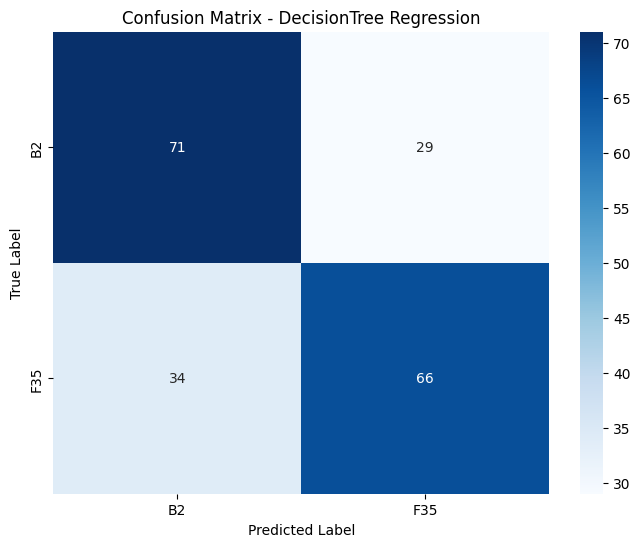

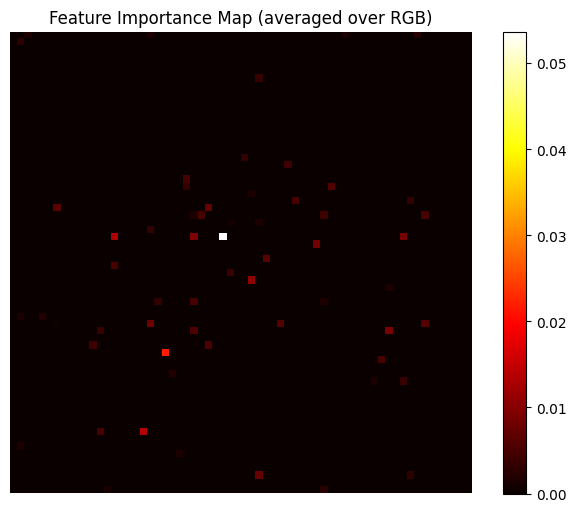

In [10]:
# 步骤六：结果保存与可视化
# 6.1 绘制并保存混淆矩阵热力图
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DecisionTree Regression")
plt.savefig('./output/sklearn_decisionTree_confusion_matrix.png')
plt.show()

# 步骤6.2：特征重要性可视化
importances = clf.feature_importances_
importance_map = importances.reshape(3, *image_size).mean(axis=0)
plt.figure(figsize=(8, 6))
plt.imshow(importance_map, cmap='hot')
plt.colorbar()
plt.title("Feature Importance Map (averaged over RGB)")
plt.axis('off')
plt.savefig('./output/decision_tree_feature_importance.png')
plt.show()

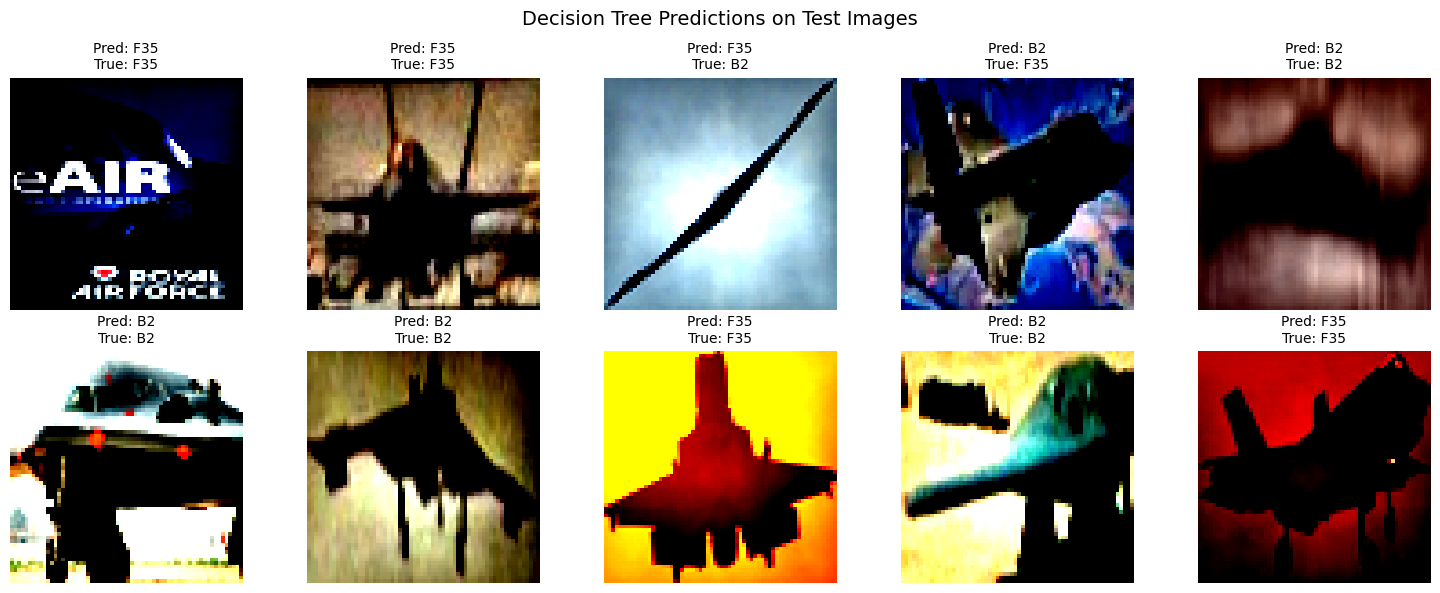

In [11]:
# 步骤七：推理结果可视化（展示若干张测试图像及预测结果）
def visualize_predictions(X_test_raw, y_true, y_pred, class_names, shape=(64, 64), num_images=10):
    """
    随机选择若干张测试图像，显示其预测结果与真实标签
    """
    indices = np.random.choice(len(X_test_raw), num_images, replace=False)  # 请在此处编写代码：随机选择num_images个样本索引
    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(indices):
        img_array = X_test_raw[idx]
        true_label = y_true[idx]  # 请在此处编写代码：获取真实标签
        pred_label = y_pred[idx]  # 请在此处编写代码：获取预测标签

        # 还原图像：一维向量 -> (3, H, W) -> (H, W, 3)
        img = img_array.reshape(3, *shape).transpose(1, 2, 0)  # 请在此处编写代码：reshape并transpose为可显示图像格式
        img = np.clip(img, 0, 1)  # 请在此处编写代码：限制像素值在0-1范围（使用np.clip）

        plt.subplot(2, (num_images + 1) // 2, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}", fontsize=10)
        plt.axis('off')

    plt.suptitle("Decision Tree Predictions on Test Images", fontsize=14)
    plt.tight_layout()
    plt.savefig('./output/decision_tree_test_predictions.png')
    plt.show()

# 步骤七调用：推理可视化函数
visualize_predictions(X_test, y_test, y_pred, classes, shape=image_size, num_images=10)